# Machine Learning
## Predicting Labor Force Participation Rate

**Task**: Regression — predict a country's participation rate for a given year using its own recent history (lag features) and the year itself.

**Why lag features?** EDA showed each country has a fairly stable, path-dependent trend (e.g. Rwanda stays high, China steadily declines). A country's rate last year is a strong predictor of its rate this year — much stronger than year or country identity alone.

**Split strategy**: TIME-BASED, not random. We train on years up to 2020 and test on 2021-2025. This mirrors how the model would actually be used (predicting the future from the past) and avoids leaking future information into training, which a random split would risk since rows from the same country appear across years.

In [19]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
sys.path.append('..')
from src.config import DATABASE_URL, BASE_DIR
from sqlalchemy import create_engine

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
DOCS_DIR = os.path.join(BASE_DIR, 'docs')
os.makedirs(DOCS_DIR, exist_ok=True)

engine = create_engine(DATABASE_URL)
df = pd.read_sql('SELECT * FROM clean_labor_force ORDER BY country_iso3, year', engine)
df.shape

(6718, 6)

## 1. Feature Engineering: Lag Features

In [20]:
# For each country, create lag1 (previous year's rate) and lag2 (two years prior)
df = df.sort_values(['country_iso3', 'year']).reset_index(drop=True)
df['lag1'] = df.groupby('country_iso3')['labor_force_participation_rate'].shift(1)
df['lag2'] = df.groupby('country_iso3')['labor_force_participation_rate'].shift(2)

# Drop rows where lag features aren't available (first two years for each country)
model_df = df.dropna(subset=['lag1', 'lag2']).copy()
print(f"Rows before dropping missing lags: {len(df)}")
print(f"Rows after (usable for modeling): {len(model_df)}")
model_df[['country_name', 'year', 'lag2', 'lag1', 'labor_force_participation_rate']].head(10)

Rows before dropping missing lags: 6718
Rows after (usable for modeling): 6344


,country_name,year,lag2,lag1,labor_force_participation_rate
2,Afghanistan,1992,47.186,47.140,47.087
3,Afghanistan,1993,47.140,47.087,47.024
4,Afghanistan,1994,47.087,47.024,46.950
5,Afghanistan,1995,47.024,46.950,46.876
6,Afghanistan,1996,46.950,46.876,46.803
7,Afghanistan,1997,46.876,46.803,46.732
8,Afghanistan,1998,46.803,46.732,46.667
9,Afghanistan,1999,46.732,46.667,46.609
10,Afghanistan,2000,46.667,46.609,46.562
11,Afghanistan,2001,46.609,46.562,46.526


## 2. Time-Based Train/Test Split

In [21]:
FEATURES = ['year', 'lag1', 'lag2']
TARGET = 'labor_force_participation_rate'

train = model_df[model_df['year'] <= 2020]
test = model_df[model_df['year'] > 2020]

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"Train: {len(X_train)} rows (years <= 2020)")
print(f"Test:  {len(X_test)} rows (years 2021-2025)")

Train: 5423 rows (years <= 2020)
Test:  921 rows (years 2021-2025)


## 3. Model 1: Linear Regression

In [22]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression:")
print(f"  MAE:  {lr_mae:.3f}")
print(f"  RMSE: {lr_rmse:.3f}")
print(f"  R^2:  {lr_r2:.3f}")

Linear Regression:
  MAE:  0.777
  RMSE: 1.335
  R^2:  0.985


## 4. Model 2: Random Forest Regressor

In [23]:
rf = RandomForestRegressor(max_depth=6, n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Regressor (max_depth=6, n_estimators=200):")
print(f"  MAE:  {rf_mae:.3f}")
print(f"  RMSE: {rf_rmse:.3f}")
print(f"  R^2:  {rf_r2:.3f}")

Random Forest Regressor (max_depth=6, n_estimators=200):
  MAE:  1.055
  RMSE: 1.543
  R^2:  0.981


## 5. Overfitting / Underfitting Check
Comparing train vs. test R^2 across different `max_depth` values for the Random Forest, following the same pattern shown in the assignment's Section 5.2 example.

In [24]:
depths = [2, 4, 6, 8, 12, None]
results = []

for depth in depths:
    model = RandomForestRegressor(max_depth=depth, n_estimators=200, random_state=42)
    model.fit(X_train, y_train)
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))
    results.append({'max_depth': str(depth), 'train_r2': train_r2, 'test_r2': test_r2})
    print(f"max_depth={str(depth):>5}  train R^2={train_r2:.3f}  test R^2={test_r2:.3f}")

results_df = pd.DataFrame(results)

max_depth=    2  train R^2=0.906  test R^2=0.891
max_depth=    4  train R^2=0.991  test R^2=0.985
max_depth=    6  train R^2=0.995  test R^2=0.981
max_depth=    8  train R^2=0.997  test R^2=0.972
max_depth=   12  train R^2=0.998  test R^2=0.968
max_depth= None  train R^2=0.999  test R^2=0.968


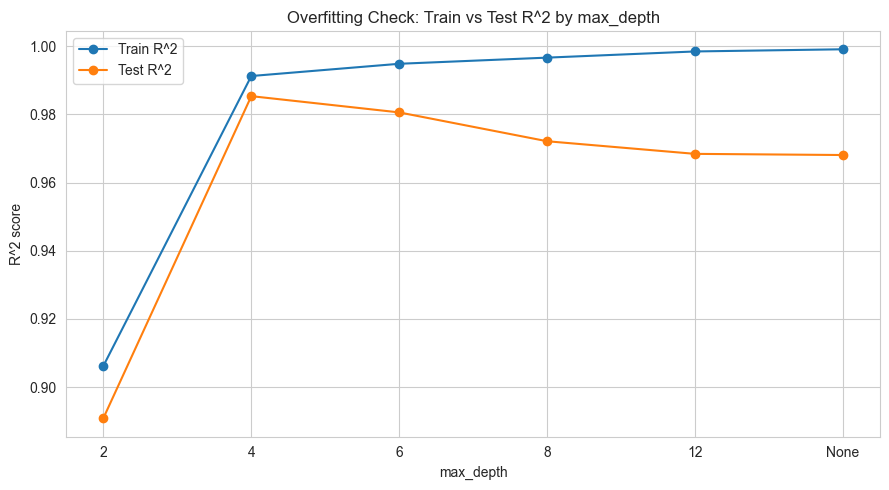

In [25]:
plt.figure(figsize=(9, 5))
x = range(len(results_df))
plt.plot(x, results_df['train_r2'], marker='o', label='Train R^2')
plt.plot(x, results_df['test_r2'], marker='o', label='Test R^2')
plt.xticks(x, results_df['max_depth'])
plt.xlabel('max_depth')
plt.ylabel('R^2 score')
plt.title('Overfitting Check: Train vs Test R^2 by max_depth')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(DOCS_DIR, 'ml_overfitting_check.png'), dpi=150)
plt.show()

## 6. Predictions vs Actual (for Tableau)
This exports a CSV with actual vs predicted values from the best model (Random Forest, max_depth=6) — required for the ML-based chart in your Tableau dashboard (Section 4.4).

In [26]:
predictions_export = test[['country_name', 'country_iso3', 'year', TARGET]].copy()
predictions_export['predicted_rate'] = rf_preds
predictions_export['linear_regression_predicted'] = lr_preds
predictions_export = predictions_export.rename(columns={TARGET: 'actual_rate'})

export_path = os.path.join(BASE_DIR, 'data', 'clean', 'ml_predictions.csv')
predictions_export.to_csv(export_path, index=False)
print(f"Saved predictions to: {export_path}")
predictions_export.head()

Saved predictions to: E:\DOWLOADS\Intro to Big Data Project\data\clean\ml_predictions.csv


,country_name,country_iso3,year,actual_rate,predicted_rate,linear_regression_predicted
31,Afghanistan,AFG,2021,40.684,41.420811,41.133981
32,Afghanistan,AFG,2022,37.640,40.999060,40.411090
33,Afghanistan,AFG,2023,37.588,37.909347,37.082807
34,Afghanistan,AFG,2024,37.547,37.822048,37.419679
35,Afghanistan,AFG,2025,37.457,37.779261,37.370554


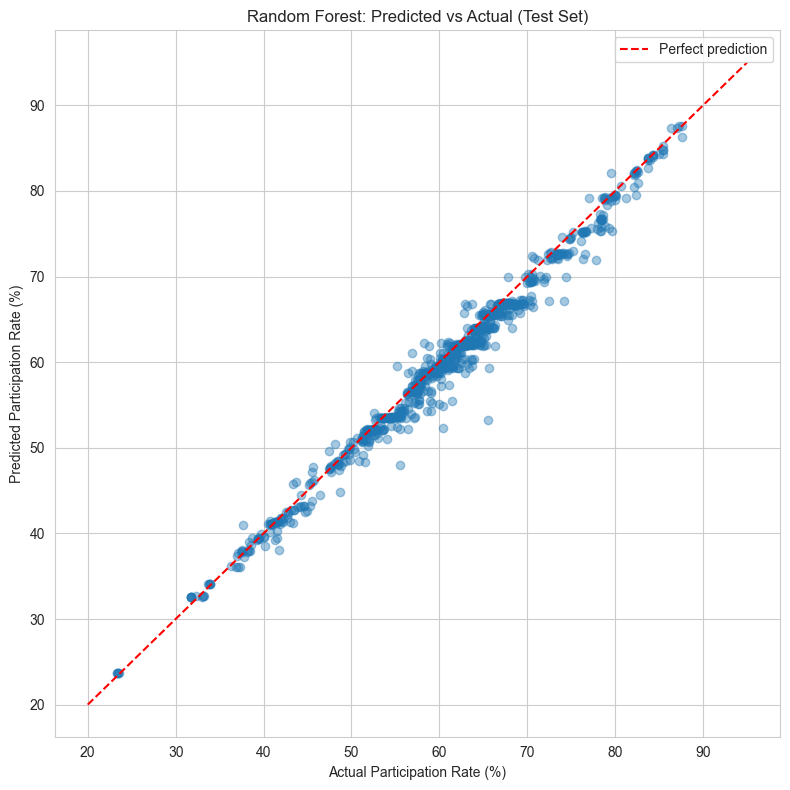

In [27]:
plt.figure(figsize=(8, 8))
plt.scatter(predictions_export['actual_rate'], predictions_export['predicted_rate'], alpha=0.4)
lims = [20, 95]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Participation Rate (%)')
plt.ylabel('Predicted Participation Rate (%)')
plt.title('Random Forest: Predicted vs Actual (Test Set)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(DOCS_DIR, 'ml_predicted_vs_actual.png'), dpi=150)
plt.show()

## 7. Written Conclusion

Linear Regression slightly outperformed Random Forest on this task (MAE 0.777 vs 1.055, R² 0.985 vs 0.981). This makes sense given the feature set: the target (this year's rate) is overwhelmingly explained by lag1 and lag2 (last year's and two years ago's rate), which is a near-linear relationship, a country's participation rate rarely jumps sharply year to year. Random Forest's extra flexibility to model non-linear splits wasn't needed here and slightly hurt generalization instead of helping it.

The overfitting check confirms this: at max_depth=2 both train and test R² are low (underfitting, the model is too simple). Performance improves sharply up to max_depth=4-6, where train and test R² stay close together. Beyond that, train R² keeps climbing toward 0.999 while test R² actually declines to 0.968 — classic overfitting, where the model starts memorizing training-specific noise instead of generalizing. max_depth=6 was kept as a reasonable middle ground, matching the assignment's own example.